$$
\frac{f(x+h)-f(x)}{h}
$$

$$
\text{Gradient}=\frac{\partial L}{\partial W}
$$

- 모델: $\hat{y}=Wx$ (bias 생략)
- 손실(한 샘플): $L=(y-\hat{y})^2=(y-Wx)^2$

이제 $W$로 미분하면:

$$
\frac{dL}{dW}
= 2(y-Wx)\cdot\frac{d(y-Wx)}{dW}
= 2(y-Wx)\cdot(-x)
= -2x(y-Wx)
$$

이 값이 바로 **기울기**입니다.

In [226]:
# y = wx
x , y = 2,4
w = 1
lr = 0.1

predict = w*x
L = (y - predict)**2
print(f'step1 w: {w}, loss: {L}')
gradient = -2*x*(y - predict)
w = w - lr*gradient
print(f'step1 new w: {w}, gradient: {gradient}')

predict = w*x
L = (y - predict)**2
print(f'step2 w: {w}, loss: {L}')
gradient = -2*x*(y - predict)
w = w - lr*gradient
print(f'step2 new w: {w}, gradient: {gradient}')

predict = w*x
L = (y - predict)**2
print(f'step3 w: {w}, loss: {L}')
gradient = -2*x*(y - predict)
w = w - lr*gradient
print(f'step3 new w: {w}, gradient: {gradient}')

step1 w: 1, loss: 4
step1 new w: 1.8, gradient: -8
step2 w: 1.8, loss: 0.15999999999999992
step2 new w: 1.96, gradient: -1.5999999999999996
step3 w: 1.96, loss: 0.006400000000000012
step3 new w: 1.992, gradient: -0.3200000000000003


In [227]:
# y = wx
import numpy as np
x , y = 2,4
w = np.random.rand()
lr = 0.1
epochs = 100

for epoch in range(epochs):
    predict = w*x
    L = (y - predict)**2
    print(f'step{epoch + 1} w: {w}, loss: {L}')
    gradient = -2*x*(y - predict)
    w = w - lr*gradient
    print(f'step{epoch + 1} new w: {w}, gradient: {gradient}\n')

step1 w: 0.41807546223606307, loss: 10.009940972718582
step1 new w: 1.6836150924472126, gradient: -12.655396302111495

step2 w: 1.6836150924472126, loss: 0.40039763890874325
step2 new w: 1.9367230184894426, gradient: -2.531079260422299

step3 w: 1.9367230184894426, loss: 0.016015905556349685
step3 new w: 1.9873446036978886, gradient: -0.5062158520844591

step4 w: 1.9873446036978886, loss: 0.0006406362222539829
step4 new w: 1.9974689207395777, gradient: -0.10124317041689146

step5 w: 1.9974689207395777, loss: 2.5625448890159316e-05
step5 new w: 1.9994937841479155, gradient: -0.020248634083378292

step6 w: 1.9994937841479155, loss: 1.0250179556067322e-06
step6 new w: 1.9998987568295832, gradient: -0.004049726816676369

step7 w: 1.9998987568295832, loss: 4.100071822419735e-08
step7 new w: 1.9999797513659165, gradient: -0.0008099453633345632

step8 w: 1.9999797513659165, loss: 1.6400287289822817e-09
step8 new w: 1.9999959502731832, gradient: -0.0001619890726676232

step9 w: 1.9999959502731

In [228]:
# (2,4)
x = 2
y = w*x
print(f'predict: {y}')
# 기울기가 + 면 w을 늘리면 손실이 증가한다. 

predict: 4.0


In [229]:
# 사과 사격 : 100원
# 사과 개수 : 2개
# 소비세 : 1.1
# z = (100 x 2)x 1.1 

# 순전파(앞으로 계산)
# a = 100 x 2 = 200
# z = a x 1.1 = 220

# 최종금액이 1원 변할때 사과가격은 얼마나 변할까?

$\frac{\partial z}{\partial 100}$
- 체인룰
$$
\frac{\partial z}{\partial 100}
=
\frac{\partial z}{\partial a}
\cdot
\frac{\partial a}{\partial 100}
$$
- 계산
- $\frac{\partial z}{\partial a}=1.1$  (세금 곱하기)
- $\frac{\partial a}{\partial 100}=2$  (개수 2개 곱하기)

따라서

$$
\frac{\partial z}{\partial 100}=1.1\times2=2.2
$$



In [230]:
# 출력까지 여러연산으로 이루어져 있음
# 각 구간의 로컬변화율(미분)을 곱해서
# 최종적으로 DL / DW 구함

# 체인룰 : 출력오차가 앞단 가중치까지 어떻게 전파되는지 계산하는 규칙
# 이 값으로 w - lr*gradient 업데이트 수행

# 신경망(은닉층1, 출력층 1) --> 체이닝룰  
# 입력 x
# 은닉층 z1 = w1x + b1  , h = relu(z1)
# 출력층 z2 = w2h + b2,  yhat = sigmoid(z2)
# 손실 L  1/2(y - yhat)**2

- 출력층 미분

$$
\frac{\partial L}{\partial w_2}
=
\frac{\partial L}{\partial \hat{y}}
\cdot
\frac{\partial \hat{y}}{\partial z_2}
\cdot
\frac{\partial z_2}{\partial w_2}
$$

- $\frac{\partial L}{\partial \hat{y}}=\hat{y}-y$
- $\frac{\partial \hat{y}}{\partial z_2}=\hat{y}(1-\hat{y})$ (시그모이드 미분)
- $\frac{\partial z_2}{\partial w_2}=h$

따라서
$$
\frac{\partial L}{\partial w_2}
=
(\hat{y}-y)\hat{y}(1-\hat{y})h
$$


- 은닉층 가중치 미분

$$
\frac{\partial L}{\partial w_1}
=
\frac{\partial L}{\partial \hat{y}}
\cdot
\frac{\partial \hat{y}}{\partial z_2}
\cdot
\frac{\partial z_2}{\partial h}
\cdot
\frac{\partial h}{\partial z_1}
\cdot
\frac{\partial z_1}{\partial w_1}
$$

각 항:

- $\frac{\partial z_2}{\partial h}=w_2$
- $\frac{\partial h}{\partial z_1}=h(1-h)$
- $\frac{\partial z_1}{\partial w_1}=x$

따라서
$$
\frac{\partial L}{\partial w_1}
=
(\hat{y}-y)\hat{y}(1-\hat{y})w_2h(1-h)x
$$


가중치 업데이트는 둘 다 동일합니다:
$$
w \leftarrow w-\eta\frac{\partial L}{\partial w}
$$

In [231]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [232]:
# 기울기
# f(x) = x^2 f'(x) = 2x

h_value = [1.0, 0.5, 0.1, 0.01, 0.001]

x0 = 3.0
f_prime = 2*x0

for h in h_value:
    gradient = ((x0+h)**2 - x0**2) / h
    print(f'두점의 기울기 : {gradient}')

print(f'이론상 접선 기울기 : {2*x0}')

두점의 기울기 : 7.0
두점의 기울기 : 6.5
두점의 기울기 : 6.100000000000012
두점의 기울기 : 6.009999999999849
두점의 기울기 : 6.000999999999479
이론상 접선 기울기 : 6.0


In [233]:
# 과일에제를 체인룰 코드 증명
# z = (사과가격 x 개수) x 세율

# DZ / D사과가격 = 개수 x 세율

import torch
apple_price = torch.tensor(100.0, requires_grad=True)
apple_count = 2.0
tax = 1.1

subtotal = apple_price * apple_count
total_price = subtotal * tax

total_price.backward()

manual_gradient = apple_count * tax
auto_gradient = apple_price.grad.item()

print(manual_gradient, auto_gradient)

2.2 2.200000047683716


In [234]:
# f(x) = x^2
x_manual = 4.0 #시작점
lr = 0.1
manual_history = [x_manual]

for step in range(20):
    gradient = 2 * x_manual
    x_manual = x_manual - lr*gradient
    manual_history.append(x_manual)
    if step < 8 or step >=18:
        print(f'step {step+1} : x={x_manual:.4f} 기울기 = {gradient:.4f} f(x) = {x_manual**2:.4f}')
    elif step == 8:
        print('---------중간생략---------')

print(f'최종도달위치 : x = {x_manual:.6f} (목표 0.0)')

step 1 : x=3.2000 기울기 = 8.0000 f(x) = 10.2400
step 2 : x=2.5600 기울기 = 6.4000 f(x) = 6.5536
step 3 : x=2.0480 기울기 = 5.1200 f(x) = 4.1943
step 4 : x=1.6384 기울기 = 4.0960 f(x) = 2.6844
step 5 : x=1.3107 기울기 = 3.2768 f(x) = 1.7180
step 6 : x=1.0486 기울기 = 2.6214 f(x) = 1.0995
step 7 : x=0.8389 기울기 = 2.0972 f(x) = 0.7037
step 8 : x=0.6711 기울기 = 1.6777 f(x) = 0.4504
---------중간생략---------
step 19 : x=0.0576 기울기 = 0.1441 f(x) = 0.0033
step 20 : x=0.0461 기울기 = 0.1153 f(x) = 0.0021
최종도달위치 : x = 0.046117 (목표 0.0)


In [235]:
import torch

x_pt = torch.tensor([4.0], requires_grad=True)
optimizer = torch.optim.SGD([x_pt], lr=0.1)

pt_history = [x_pt.item()]

for step in range(20):
    optimizer.zero_grad() 

    loss = x_pt**2
    loss.backward()  # 자동미분

    optimizer.step()  # 업데이트

    pt_history.append(x_pt.item())

    if step < 3:
        print(f'step {step+1} : x={x_pt.item():.4f}, '
              f'기울기 = {x_pt.grad.item():.4f}, '
              f'f(x) = {(x_pt.item()**2):.4f}')

step 1 : x=3.2000, 기울기 = 8.0000, f(x) = 10.2400
step 2 : x=2.5600, 기울기 = 6.4000, f(x) = 6.5536
step 3 : x=2.0480, 기울기 = 5.1200, f(x) = 4.1943


In [236]:
pt_history

[4.0,
 3.200000047683716,
 2.559999942779541,
 2.047999858856201,
 1.6383998394012451,
 1.3107198476791382,
 1.0485758781433105,
 0.8388606905937195,
 0.6710885763168335,
 0.5368708372116089,
 0.4294966757297516,
 0.3435973525047302,
 0.2748778760433197,
 0.21990230679512024,
 0.17592184245586395,
 0.14073747396469116,
 0.11258997768163681,
 0.09007198363542557,
 0.07205758988857269,
 0.057646073400974274,
 0.04611685872077942]

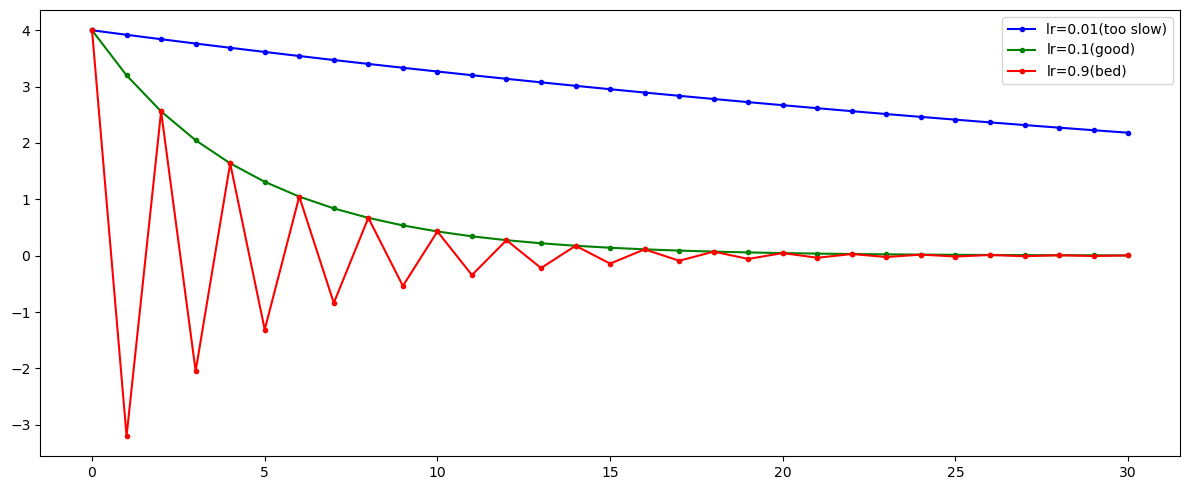

In [237]:
# 학습률
import matplotlib.pyplot as plt
learning_rate = [0.01, 0.1, 0.9]
colors = ['blue','green','red']
labels = ['lr=0.01(too slow)','lr=0.1(good)', 'lr=0.9(bed)']

fig, ax = plt.subplots(figsize=(12,5))
for lr_val, color , label in zip(learning_rate, colors, labels):
    x_test = 4.0
    history = [x_test]
    for i in range(30):
        grad = 2*x_test
        x_test = x_test - lr_val * grad
        history.append(x_test)
    ax.plot(history, marker='o', markersize=3, color=color, label = label)
plt.legend()
plt.tight_layout()
plt.show()

In [238]:
# 은닉층 1개 + 출력층 1개 : 체인률 -> backward
# z1 = w1x + b1 h = activation(z1)
# z2 = w2h + b2 h^ = activation(z2)
# L(loss) = 1/2(y-y^)**2 

In [239]:
def sigmoid(v):
    return 1/(1+torch.exp(-v))

In [240]:
# 샘플1개 초기파라메터 
x = 1.5
y = 1.0
w1, b1 = 0.5,-0.4
w2, b2 = -1.2, 0.3
lr = 0.1

# 순전파(수동)
z1 = w1*x*b1
h = 1/(1+torch.exp(torch.tensor(-z1))).item()
z2 = w2*h+b2
y_hat = 1/(1+torch.exp(torch.tensor(-z2))).item()
loss = 0.5*(y-y_hat)**5

# 체인룰 미분(수동)
dL_dyhat = (y_hat - y)
dyhat_dz2 =  y_hat*(1-y_hat)
dL_dz2 = dL_dyhat* dyhat_dz2

dL_dw2_manual = dL_dz2*h
dL_db2_manual = dL_dz2

dL_dh = dL_dz2*w2
dh_dz1 = h*(1-h)
dL_dz1 = dL_dh * dh_dz1

dL_dw1_manual = dL_dz1*x
dL_db1_manual = dL_dz1

print(f'dL/dw1 = {dL_dw1_manual} dL/db1 = {dL_db1_manual}')
print(f'dL/dw2 = {dL_dw2_manual} dL/db2 = {dL_db2_manual}')

dL/dw1 = 0.060106145511444796 dL/db1 = 0.04007076367429653
dL/dw2 = -0.058129930457308104 dL/db2 = -0.13659712635176152


In [241]:
# autograde
x_t = torch.tensor([x], dtype=torch.float32)
y_t = torch.tensor([y], dtype=torch.float32)
w1_t = torch.tensor([w1], dtype=torch.float32, requires_grad=True)
b1_t = torch.tensor([b1], dtype=torch.float32, requires_grad=True)
w2_t = torch.tensor([w2], dtype=torch.float32, requires_grad=True)
b2_t = torch.tensor([b2], dtype=torch.float32, requires_grad=True)

h_t = sigmoid(w1_t*x + b1_t)
yhat_t = sigmoid(w2_t * h_t + b2_t)
loss_t = 0.5 * (yhat_t - y_t)**2
loss_t.backward()

print(f'dL/dw1 = {w1_t.grad.item()} dL/db1 = {b1_t.grad.item()}')
print(f'dL/dw1 = {w2_t.grad.item()} dL/db1 = {b2_t.grad.item()}')

abs(dL_dw1_manual-w1_t.grad.item()), abs(dL_db1_manual-b1_t.grad.item())

dL/dw1 = 0.06283612549304962 dL/db1 = 0.04189075157046318
dL/dw1 = -0.08444712311029434 dL/db1 = -0.1439560055732727


(0.0027299799816048256, 0.00181998789616665)

In [242]:
# 경사하강법
with torch.no_grad():
  w1_new = w1_t - lr*w1_t.grad
  b1_new = b1_t - lr*b1_t.grad
  w2_new = w2_t - lr*w2_t.grad
  b2_new = b2_t - lr*b2_t.grad

  h_new = sigmoid(w1_new*x_t+b1_new)
  yhat_new = sigmoid(w2_new * h_new + b2_new)
  loss_new = 0.5*(yhat_new-y_t)**2

  print(f'업데이트전 loss : {loss_t.item()}')
  print(f'업데이트후 loss : {loss_new.item()}')

업데이트전 loss : 0.17978057265281677
업데이트후 loss : 0.176436185836792


In [243]:
class Chain_Test:
    def __init__(self):
        self.year = 0
        self.month = 0
        self.day = 0
    def setyear(self, year):
        self.year = year
        return self
    def setmonth(self, month):
        self.month = month
        return self
    def setday(self, day):
        self.day = day
        return self

chain = Chain_Test()
chain.setyear('2026').setmonth('04').setday('22')

In [244]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
titanic = sns.load_dataset('titanic')
# 학습용 데이터 정답을 분리
# 훈련 검증 테스트 데이터 분리
# pytorch로 신경망 구성
# 손실함수는 BCEloss
# optimizer adam lr = 기본값

In [256]:
import seaborn as sns
titanic = sns.load_dataset('titanic')

# 수치형 standard....  범주형  onehot
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import torch
y = titanic['survived'].to_numpy()
X =titanic.loc[:,'pclass':]
X = X.drop(['class','sex','embark_town','alive','deck'], axis=1)

numeric_cols = ['pclass','age','sibsp','parch','fare']
categorical_cols = ['embarked','who','adult_male','alone']
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder())
])

transformer = ColumnTransformer(
    transformers=[
        ('num',numeric_pipe,numeric_cols),
        ('cat',categorical_pipe,categorical_cols)
    ]
)

x_train_full,x_test,y_train_full,y_test = train_test_split(X,y,stratify=y, random_state=42)
x_train,x_val,y_train,y_val = train_test_split(x_train_full, y_train_full, stratify=y_train_full, random_state=42)

In [257]:
x_train = transformer.fit_transform(x_train)
x_val = transformer.transform(x_val)
x_test = transformer.transform(x_test)

In [258]:
import torch.nn as nn
class TitanicDNN(nn.Module):
  def __init__(self,input_dim=15):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear( input_dim , 40 ),        
        nn.ReLU(),        
        nn.Linear(40,1),
        nn.Sigmoid()
    )
  def forward(self, x):
    return self.net(x)

model = TitanicDNN()

In [259]:
x_train_t = torch.tensor( x_train,dtype=torch.float32)
x_val_t = torch.tensor( x_val,dtype=torch.float32)
x_test_t = torch.tensor( x_test,dtype=torch.float32)

y_train_t = torch.tensor( y_train,dtype=torch.float32)
y_val_t = torch.tensor( y_val,dtype=torch.float32)
y_test_t = torch.tensor( y_test,dtype=torch.float32)

In [260]:
# 손실함수
bce = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 100
train_losses, val_losses = [],[]
for epoch in range(epochs):  
  # forward
  predict = model(x_train_t)    
  loss = bce(predict, y_train_t.unsqueeze(1))
  # backward
  loss.backward()
  # 업데이트
  optimizer.step()
  # 가중치초기화
  optimizer.zero_grad()

  # val 으로 epoch 추론
  with torch.no_grad():
    val_output = model(x_val_t)
    val_loss = bce(val_output, y_val_t.unsqueeze(1))    

  print(f'epoch : {epoch+1} loss:{loss.item():.4f} val_loss : {val_loss.item():.4f}')
  train_losses.append(loss.item())
  val_losses.append(val_loss.item())

epoch : 1 loss:0.7022 val_loss : 0.7048
epoch : 2 loss:0.7019 val_loss : 0.7044
epoch : 3 loss:0.7015 val_loss : 0.7040
epoch : 4 loss:0.7011 val_loss : 0.7036
epoch : 5 loss:0.7008 val_loss : 0.7032
epoch : 6 loss:0.7004 val_loss : 0.7028
epoch : 7 loss:0.7000 val_loss : 0.7024
epoch : 8 loss:0.6997 val_loss : 0.7021
epoch : 9 loss:0.6993 val_loss : 0.7017
epoch : 10 loss:0.6989 val_loss : 0.7013
epoch : 11 loss:0.6986 val_loss : 0.7009
epoch : 12 loss:0.6982 val_loss : 0.7005
epoch : 13 loss:0.6978 val_loss : 0.7001
epoch : 14 loss:0.6975 val_loss : 0.6997
epoch : 15 loss:0.6971 val_loss : 0.6993
epoch : 16 loss:0.6967 val_loss : 0.6989
epoch : 17 loss:0.6964 val_loss : 0.6985
epoch : 18 loss:0.6960 val_loss : 0.6981
epoch : 19 loss:0.6957 val_loss : 0.6977
epoch : 20 loss:0.6953 val_loss : 0.6973
epoch : 21 loss:0.6949 val_loss : 0.6969
epoch : 22 loss:0.6946 val_loss : 0.6966
epoch : 23 loss:0.6942 val_loss : 0.6962
epoch : 24 loss:0.6938 val_loss : 0.6958
epoch : 25 loss:0.6935 va

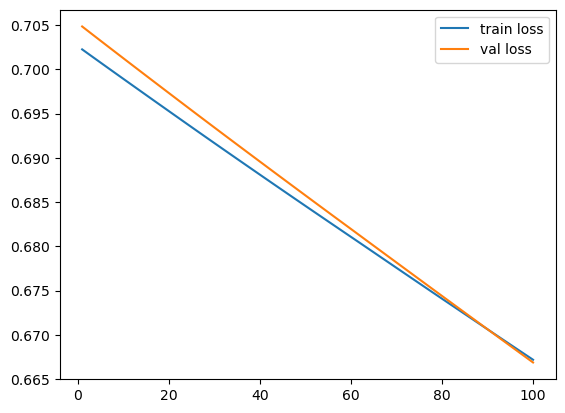

In [261]:
import matplotlib.pyplot as plt
plt.plot(range(1,epochs+1), train_losses, label = 'train loss')
plt.plot(range(1,epochs+1), val_losses, label = 'val loss')
plt.legend()
plt.show()

In [262]:
((model(x_test_t) >= 0.5).float().squeeze(1) == y_test_t).float().mean()

tensor(0.6143)

In [263]:
%pip install flaml[automl]

Note: you may need to restart the kernel to use updated packages.


In [253]:
from flaml import AutoML

In [254]:
automl = AutoML()
automl_settings = {
    "time_budget": 1,  # in seconds
    "metric": "accuracy",
    "task": "classification",
    "log_file_name": "iris.log",
}
automl.fit(X_train=x_train, y_train=y_train, **automl_settings)

[flaml.automl.logger: 04-22 17:37:00] {2375} INFO - task = classification
[flaml.automl.logger: 04-22 17:37:00] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-22 17:37:00] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 04-22 17:37:00] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost', 'lrl1']
[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-22 17:37:00] {3046} INFO - Estimated sufficient time budget=362s. Estimated necessary time budget=9s.
[flaml.automl.logger: 04-22 17:37:00] {3097} INFO -  at 0.0s,	estimator lgbm's best error=3.2333e-01,	best estimator lgbm's best error=3.2333e-01
[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-22 17:37:00] {3097} INFO -  at 0.1s,	estimator lgbm's best error=3.2333e-01,	best estimator lgbm's best error=3.2333e-01
[

c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMCla

[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 6, current learner lgbm
[flaml.automl.logger: 04-22 17:37:00] {3097} INFO -  at 0.3s,	estimator lgbm's best error=2.7476e-01,	best estimator sgd's best error=2.3381e-01
[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 04-22 17:37:00] {3097} INFO -  at 0.3s,	estimator lgbm's best error=2.7476e-01,	best estimator sgd's best error=2.3381e-01
[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 8, current learner sgd
[flaml.automl.logger: 04-22 17:37:00] {3097} INFO -  at 0.3s,	estimator sgd's best error=2.3381e-01,	best estimator sgd's best error=2.3381e-01
[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 9, current learner sgd
[flaml.automl.logger: 04-22 17:37:00] {3097} INFO -  at 0.4s,	estimator sgd's best error=2.2476e-01,	best estimator sgd's best error=2.2476e-01
[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 10, current learne

c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMCla

[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 13, current learner sgd
[flaml.automl.logger: 04-22 17:37:00] {3097} INFO -  at 0.4s,	estimator sgd's best error=2.0524e-01,	best estimator sgd's best error=2.0524e-01
[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 14, current learner sgd
[flaml.automl.logger: 04-22 17:37:00] {3097} INFO -  at 0.5s,	estimator sgd's best error=2.0524e-01,	best estimator sgd's best error=2.0524e-01
[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 15, current learner xgboost
[flaml.automl.logger: 04-22 17:37:00] {3097} INFO -  at 0.5s,	estimator xgboost's best error=3.2333e-01,	best estimator sgd's best error=2.0524e-01
[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 16, current learner sgd
[flaml.automl.logger: 04-22 17:37:00] {3097} INFO -  at 0.5s,	estimator sgd's best error=2.0524e-01,	best estimator sgd's best error=2.0524e-01
[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 17, curren

c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMCla

[flaml.automl.logger: 04-22 17:37:00] {3097} INFO -  at 0.9s,	estimator extra_tree's best error=2.7429e-01,	best estimator sgd's best error=2.0524e-01
[flaml.automl.logger: 04-22 17:37:00] {2911} INFO - iteration 21, current learner rf
[flaml.automl.logger: 04-22 17:37:01] {3097} INFO -  at 1.0s,	estimator rf's best error=2.8333e-01,	best estimator sgd's best error=2.0524e-01
[flaml.automl.logger: 04-22 17:37:01] {2911} INFO - iteration 22, current learner sgd
[flaml.automl.logger: 04-22 17:37:01] {3097} INFO -  at 1.0s,	estimator sgd's best error=2.0524e-01,	best estimator sgd's best error=2.0524e-01
[flaml.automl.logger: 04-22 17:37:01] {2911} INFO - iteration 23, current learner catboost
[flaml.automl.logger: 04-22 17:37:01] {3097} INFO -  at 1.5s,	estimator catboost's best error=2.7333e-01,	best estimator sgd's best error=2.0524e-01
[flaml.automl.logger: 04-22 17:37:01] {3359} INFO - retrain sgd for 0.0s
[flaml.automl.logger: 04-22 17:37:01] {3362} INFO - retrained model: SGDClassi

In [255]:
sum(automl.predict(x_test) == y_test) / len(y_test), automl.best_config , automl.best_estimator

(0.782608695652174,
 {'penalty': 'None',
  'alpha': 0.00048220009927335403,
  'l1_ratio': 0.00870574889667242,
  'epsilon': 0.1,
  'learning_rate': 'constant',
  'eta0': 0.0073280898930720125,
  'power_t': 0.47436097801285154,
  'average': False,
  'loss': 'modified_huber'},
 'sgd')